In [2]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(320, 320, 3), 
    include_top=False, 
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(2, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\User\anaconda3\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)        │ (None, 576)                 │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │           1,154 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 940,274 (3.59 MB)

 Trainable params: 1,154 (4.51 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [2]:
base_model.trainable = True

print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  158


In [3]:
fine_tune_at = len(base_model.layers) - 25

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [4]:
import tensorflow as tf
import os

# 기본 설정
batch_size = 32
img_height = 320
img_width = 320
AUTOTUNE = tf.data.AUTOTUNE

# 1. 파일 경로와 라벨을 매핑해주는 전처리 함수 정의
def get_label(file_path):
    # 경로에서 클래스 이름 추출 (예: 'fail' 또는 'pass')
    parts = tf.strings.split(file_path, os.path.sep)
    class_name = parts[-2]
    # fail은 0, pass는 1로 인코딩
    return tf.cast(class_name == 'pass', tf.int32)

def process_image_with_letterbox(file_path):
    label = get_label(file_path)
    # 이미지 읽기 및 디코딩
    img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img, channels=3)
    
    # [핵심] Letterbox 적용 (비율을 유지하며 320x320으로 맞추고 남는 곳은 검은색(0) 패딩)
    img = tf.image.resize_with_pad(img, target_height=img_height, target_width=img_width)
    
    return img, label

# 2. tf.data.Dataset.list_files를 이용한 데이터 로드
train_dir = 'C:/Users/User/Downloads/RGB-20260803T005517Z-1-001/RGB/dataset/train/*/*.jpg'
test_dir = 'C:/Users/User/Downloads/RGB-20260803T005517Z-1-001/RGB/dataset/test/*/*.jpg'

# Train 데이터를 불러오고 8:2로 검증셋 분할
full_train_ds = tf.data.Dataset.list_files(train_dir, seed=123, shuffle=True)
dataset_size = tf.data.experimental.cardinality(full_train_ds).numpy()

val_size = int(dataset_size * 0.2)
train_size = dataset_size - val_size

train_files = full_train_ds.skip(val_size)
val_files = full_train_ds.take(val_size)

test_files = tf.data.Dataset.list_files(test_dir, shuffle=False)

# 3. 전처리 매핑 및 최적화(Batch, Prefetch) 적용
train_ds = (train_files
            .map(process_image_with_letterbox, num_parallel_calls=AUTOTUNE)
            .cache()
            .batch(batch_size)
            .prefetch(buffer_size=AUTOTUNE))

val_ds = (val_files
          .map(process_image_with_letterbox, num_parallel_calls=AUTOTUNE)
          .cache()
          .batch(batch_size)
          .prefetch(buffer_size=AUTOTUNE))

test_ds = (test_files
           .map(process_image_with_letterbox, num_parallel_calls=AUTOTUNE)
           .cache()
           .batch(batch_size)
           .prefetch(buffer_size=AUTOTUNE))

print("Letterbox 전처리가 적용된 데이터 파이프라인 구성이 완료되었습니다.")

Letterbox 전처리가 적용된 데이터 파이프라인 구성이 완료되었습니다.


In [5]:
class_weights_dict = {
    0: 2.0,  
    1: 1.0   
}

epochs = 10
print("학습을 시작합니다...")

history = model.fit(
    train_ds,   
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights_dict
)

학습을 시작합니다...
Epoch 1/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 191s 374ms/step - accuracy: 0.6480 - loss: 0.8292 - val_accuracy: 0.7966 - val_loss: 0.5281
Epoch 2/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 248s 523ms/step - accuracy: 0.8853 - loss: 0.4486 - val_accuracy: 0.9026 - val_loss: 0.3674
Epoch 3/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 227s 478ms/step - accuracy: 0.9337 - loss: 0.2935 - val_accuracy: 0.9334 - val_loss: 0.2560
Epoch 4/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 204s 429ms/step - accuracy: 0.9533 - loss: 0.2180 - val_accuracy: 0.9534 - val_loss: 0.1795
Epoch 5/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 206s 433ms/step - accuracy: 0.9625 - loss: 0.1752 - val_accuracy: 0.9645 - val_loss: 0.1321
Epoch 6/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 245s 515ms/step - accuracy: 0.9684 - loss: 0.1478 - val_accuracy: 0.9713 - val_loss: 0.1027
Epoch 7/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 231s 486ms/step - accuracy: 0.9723 - loss: 0.1288 - val_accuracy: 0.9753 - val_loss: 0.0840
Epoch 8/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 207s 437ms/step - accur

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(test_ds)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 409ms/step


In [7]:
y_pred = np.argmax(predictions, axis=1)

class_names = ['fail', 'pass']
print("\n=== 상세 분류 리포트 ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. 오차 행렬 (Confusion Matrix) 출력
print("\n=== 오차 행렬 (Confusion Matrix) ===")
cm = confusion_matrix(y_true, y_pred)
print(f"               [예측: fail]  [예측: pass]")
print(f"[실제: fail]       {cm[0, 0]}            {cm[0, 1]}")
print(f"[실제: pass]       {cm[1, 0]}            {cm[1, 1]}")


=== 상세 분류 리포트 ===
              precision    recall  f1-score   support

        fail       0.98      0.97      0.97       100
        pass       1.00      1.00      1.00       900

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000


=== 오차 행렬 (Confusion Matrix) ===
               [예측: fail]  [예측: pass]
[실제: fail]       97            3
[실제: pass]       2            898


In [8]:
y_pred_custom = np.where(predictions[:, 0] >= 0.3, 0, 1)

class_names = ['fail', 'pass']
print("\n=== 상세 분류 리포트 ===")
print(classification_report(y_true, y_pred_custom, target_names=class_names))

# 4. 오차 행렬 (Confusion Matrix) 출력
print("\n=== 오차 행렬 (Confusion Matrix) ===")
cm = confusion_matrix(y_true, y_pred_custom)
print(f"               [예측: fail]  [예측: pass]")
print(f"[실제: fail]       {cm[0, 0]}            {cm[0, 1]}")
print(f"[실제: pass]       {cm[1, 0]}            {cm[1, 1]}")


=== 상세 분류 리포트 ===
              precision    recall  f1-score   support

        fail       0.85      0.98      0.91       100
        pass       1.00      0.98      0.99       900

    accuracy                           0.98      1000
   macro avg       0.92      0.98      0.95      1000
weighted avg       0.98      0.98      0.98      1000


=== 오차 행렬 (Confusion Matrix) ===
               [예측: fail]  [예측: pass]
[실제: fail]       98            2
[실제: pass]       17            883


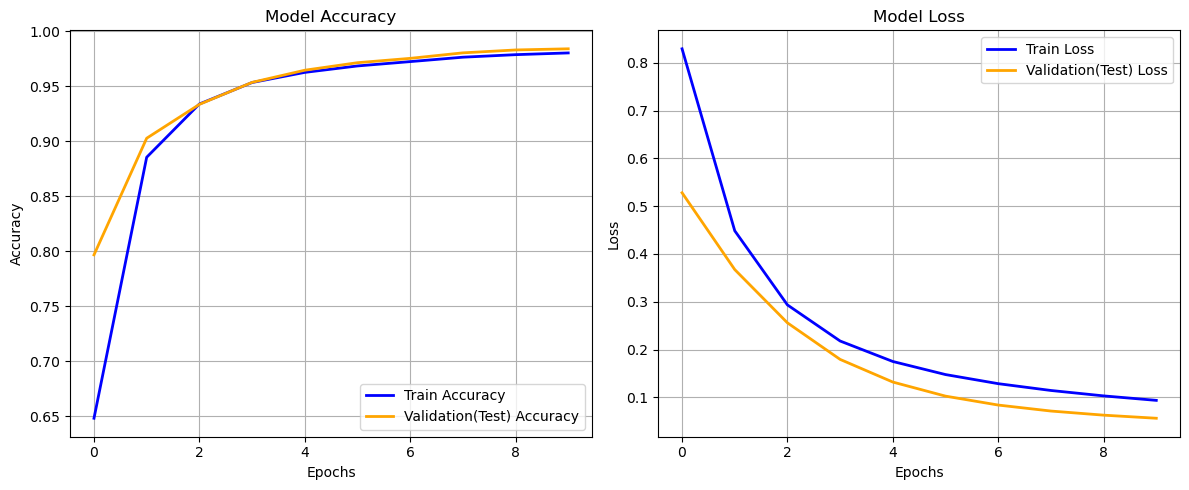

In [9]:
import matplotlib.pyplot as plt

# model.fit() 실행 결과를 history 변수에 저장했다고 가정합니다.
# 예: history = model.fit(train_dataset, validation_data=val_dataset, epochs=20, class_weight=weights)

# 1. 전체 그래프 캔버스 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# 2. 정확도(Accuracy) 그래프 그리기
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 영역
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation(Test) Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 3. 손실(Loss) 그래프 그리기
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 영역
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation(Test) Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# 4. 레이아웃 겹치지 않게 조정한 뒤 출력
plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf
import os

file_paths = [path.numpy().decode('utf-8') for path in test_files]

print(f"총 {len(file_paths)}개의 테스트 파일 경로를 성공적으로 가져왔습니다!")

총 1000개의 테스트 파일 경로를 성공적으로 가져왔습니다!


놓친 불량(미검) 개수: 3개


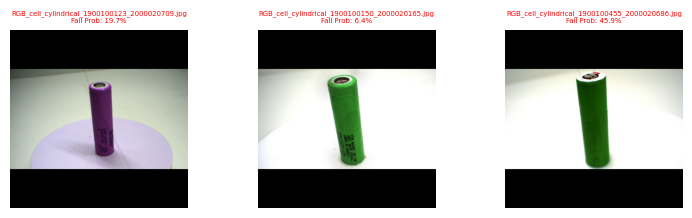

In [16]:
# 1. 미검(False Negative) 데이터의 인덱스 찾기
missed_indices = np.where((y_true == 0) & (y_pred == 1))[0]
print(f"놓친 불량(미검) 개수: {len(missed_indices)}개")

# 3. 테스트 데이터셋에서 전체 이미지 배열 가져오기
all_images = np.concatenate([x for x, y in test_ds], axis=0)

# 4. 시각화 (matplotlib)
plt.figure(figsize=(15, 10))
f_name=[]
for i, idx in enumerate(missed_indices):
    if i >= len(missed_indices):
        break
        
    plt.subplot(5, 6, i + 1)
    
    img = all_images[idx]
    if np.max(img) > 1.0:
        img = img.astype("uint8")
        
    plt.imshow(img)
    
    # [수정] 인덱스 대신 파일명 추출하기
    # os.path.basename을 사용하면 전체 경로에서 파일 이름(예: image_123.jpg)만 똑 떼어옵니다.
    filename = os.path.basename(file_paths[idx])
    
    # 모델이 불량(fail)일 확률 계산값 가져오기
    fail_prob = predictions[:, 0][idx] * 100 
    
    # 제목에 파일명과 확률 표시 (글씨가 길어질 수 있으므로 폰트 크기 조정)
    plt.title(f"{filename}\nFail Prob: {fail_prob:.1f}%", fontsize=5, color='red')
    plt.axis('off')
    f_name.append(filename)

plt.tight_layout()
plt.show()

In [17]:
f_name

['RGB_cell_cylindrical_1900100123_2000020709.jpg',
 'RGB_cell_cylindrical_1900100150_2000020165.jpg',
 'RGB_cell_cylindrical_1900100455_2000020686.jpg']

In [18]:
search_image = " OR ".join(f_name)
search_image = search_image.replace(".jpg", "")
search_image

'RGB_cell_cylindrical_1900100123_2000020709 OR RGB_cell_cylindrical_1900100150_2000020165 OR RGB_cell_cylindrical_1900100455_2000020686'

In [19]:
# C드라이브의 특정 폴더에 저장하고 싶을 때
model.save('C:/Users/User/Downloads/saved_models/inspection_model_test_3.keras')

print("원하는 디렉토리에 모델이 저장되었습니다.")

원하는 디렉토리에 모델이 저장되었습니다.
